##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [ ]:
# Install library
%pip install -q keras-cv


Image File | Detected Objects | Confidence Scores | Notes
----------------------------------------------------------------------------------------------------
boat.png | {'boat'} | [0.993] | Correctly detected boat


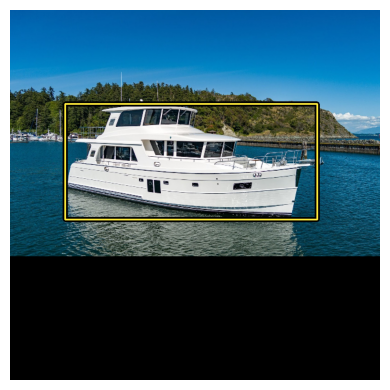

bus.png | {'bus', 'person'} | [0.986, 0.638] | Correctly detected bus


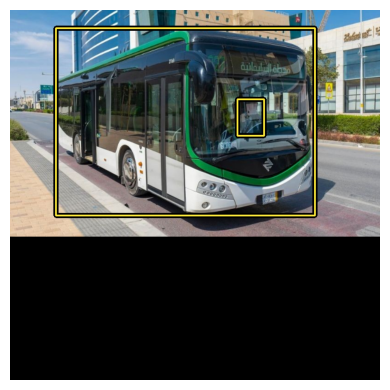

cat.png | {'cat', 'sofa', 'person'} | [0.969, 0.885, 0.324] | Correctly detected cat


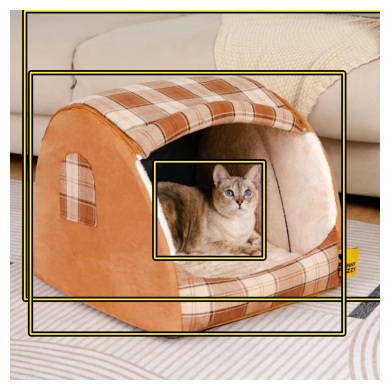

horse.png | {'dog'} | [0.772] | Missed or mislabeled horse


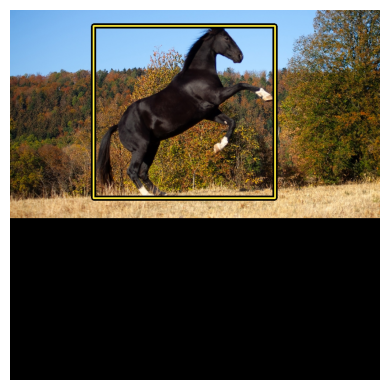

motorbike.png | {'motorbike', 'person'} | [0.991, 0.888, 0.881, 0.865] | Correctly detected motorbike


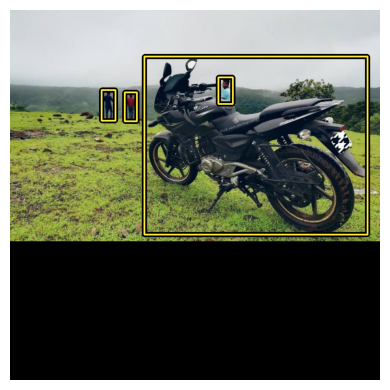

In [8]:
import os
import numpy as np
import keras_cv
import matplotlib.pyplot as plt
from PIL import Image

# Load YOLOv8 model from Pascal VOC preset
model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

# Pascal VOC class names
class_names = [
    "aeroplane", "bicycle", "bird", "boat", "bottle", "bus", "car", "cat", "chair",
    "cow", "diningtable", "dog", "horse", "motorbike", "person", "pottedplant",
    "sheep", "sofa", "train", "tvmonitor"
]

# Required resizing layer from the exercise
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

# Folder containing images
image_folder = "../images"

# Your selected PNG images and expected main object
images = {
    "boat.png": "boat",
    "bus.png": "bus",
    "cat.png": "cat",
    "horse.png": "horse",
    "motorbike.png": "motorbike"
}

# Confidence threshold for cleaner results
CONF_THRESHOLD = 0.25

print("Image File | Detected Objects | Confidence Scores | Notes")
print("-" * 100)

for file_name, true_label in images.items():
    path = os.path.join(image_folder, file_name)

    # Load image
    img = Image.open(path).convert("RGB")
    img_np = np.array(img)

    # Add batch dimension
    x = np.expand_dims(img_np, axis=0)

    # Resize as required by exercise
    x_resized = inference_resizing(x)

    # Run prediction
    preds = model.predict(x_resized, verbose=0)

    # Extract predictions
    boxes = preds["boxes"][0]
    classes = preds["classes"][0]
    confidences = preds["confidence"][0]

    detected_objects = []
    detected_scores = []

    for box, cls, score in zip(boxes, classes, confidences):
        if cls != -1 and score >= CONF_THRESHOLD:
            cls_name = class_names[int(cls)]
            detected_objects.append(cls_name)
            detected_scores.append(float(score))

    # Create note
    if true_label in detected_objects:
        note = f"Correctly detected {true_label}"
    elif len(detected_objects) == 0:
        note = f"Missed {true_label}"
    else:
        note = f"Missed or mislabeled {true_label}"

    # Print summary
    score_text = [round(s, 3) for s in detected_scores]
    print(f"{file_name} | {set(detected_objects)} | {score_text} | {note}")

    # Visualization prep
    vis_boxes = []
    vis_classes = []
    vis_confidences = []

    for box, cls, score in zip(boxes, classes, confidences):
        if cls != -1 and score >= CONF_THRESHOLD:
            vis_boxes.append(box)
            vis_classes.append(int(cls))
            vis_confidences.append(float(score))

    if len(vis_boxes) == 0:
        plt.figure(figsize=(8, 8))
        plt.imshow(img_np)
        plt.title(f"{file_name} - No detections above threshold")
        plt.axis("off")
        plt.show()
    else:
        vis_boxes = np.array(vis_boxes, dtype="float32")
        vis_classes = np.array(vis_classes, dtype="int32")
        vis_confidences = np.array(vis_confidences, dtype="float32")

        y_pred = {
            "boxes": np.expand_dims(vis_boxes, axis=0),
            "classes": np.expand_dims(vis_classes, axis=0),
            "confidence": np.expand_dims(vis_confidences, axis=0),
        }

        keras_cv.visualization.plot_bounding_box_gallery(
            images=x_resized,
            value_range=(0, 255),
            rows=1,
            cols=1,
            y_pred=y_pred,
            scale=4,
            font_scale=0.8,
            bounding_box_format="xywh",
            class_mapping=class_names,
            show=True,
        )
